In [1]:
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB

In [3]:
df = pd.read_csv("../dataset/bbc-text.csv")

# EDA (Exploratory Data Analysis)

In [6]:
df

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...
...,...,...
2220,business,cars pull down us retail figures us retail sal...
2221,politics,kilroy unveils immigration policy ex-chatshow ...
2222,entertainment,rem announce new glasgow concert us band rem h...
2223,politics,how political squabbles snowball it s become c...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [10]:
df.columns

Index(['category', 'text'], dtype='object')

In [12]:
df.shape

(2225, 2)

In [14]:
df.isnull().sum()

category    0
text        0
dtype: int64

In [16]:
df["category"].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [18]:
df["category"].unique()

array(['tech', 'business', 'sport', 'entertainment', 'politics'],
      dtype=object)

In [20]:
df['text_length'] = df['text'].apply(len)
df['text_length'].describe()

count     2225.00000
mean      2262.93618
std       1364.10253
min        501.00000
25%       1446.00000
50%       1965.00000
75%       2802.00000
max      25483.00000
Name: text_length, dtype: float64

# Visualization

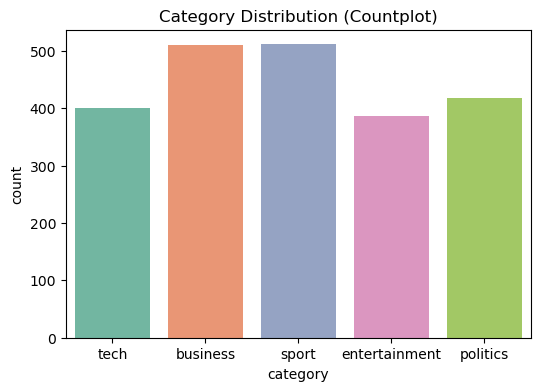

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='category', data=df, palette="Set2")
plt.title("Category Distribution (Countplot)")
plt.show()

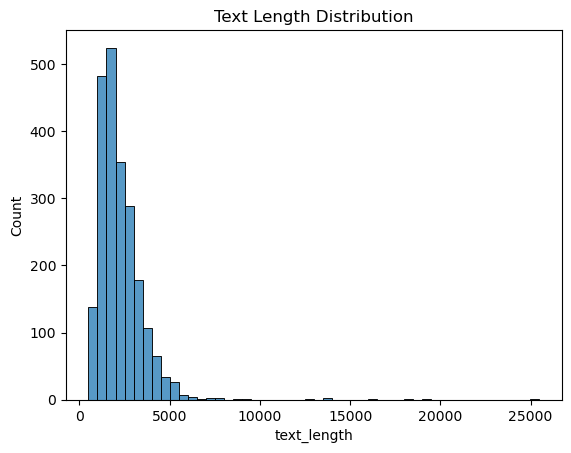

In [25]:
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

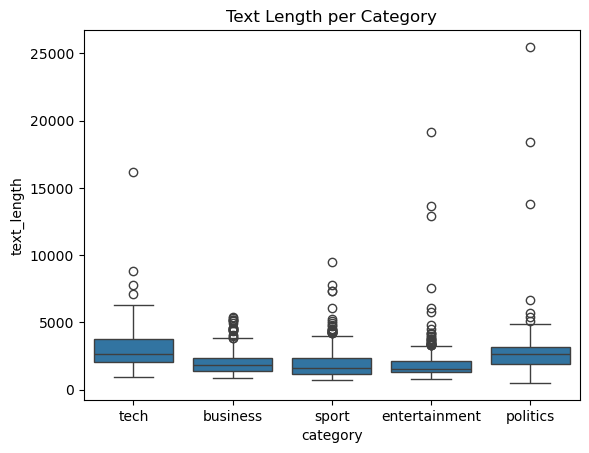

In [27]:
sns.boxplot(x='category', y='text_length', data=df)
plt.title("Text Length per Category")
plt.show()

# Preprocessing

In [30]:
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

In [32]:
df['clean_text'] = df['text'].apply(clean_text)

In [34]:
df[['text', 'clean_text']]

,text,clean_text
0,tv future in the hands of viewers with home th...,tv future in the hands of viewers with home th...
1,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...
2,tigers wary of farrell gamble leicester say ...,tigers wary of farrell gamble leicester say th...
3,yeading face newcastle in fa cup premiership s...,yeading face newcastle in fa cup premiership s...
4,ocean s twelve raids box office ocean s twelve...,ocean s twelve raids box office ocean s twelve...
...,...,...
2220,cars pull down us retail figures us retail sal...,cars pull down us retail figures us retail sal...
2221,kilroy unveils immigration policy ex-chatshow ...,kilroy unveils immigration policy exchatshow h...
2222,rem announce new glasgow concert us band rem h...,rem announce new glasgow concert us band rem h...
2223,how political squabbles snowball it s become c...,how political squabbles snowball it s become c...


### Randomly checking the texts

In [37]:
sample = df.sample(3, random_state=42)

for i, row in sample.iterrows():
    print("ORIGINAL:\n", row['text'][:300])  # first 300 chars
    print("\nCLEANED:\n", row['clean_text'][:300])
    print("\n" + "="*100 + "\n")

ORIGINAL:
 brown and blair face new rift claims for the umpteenth time  tony blair and gordon brown are said to have declared all out war on each other.  this time the alleged rift is over who should take the credit for the government s global aid and debt initiatives  particularly in the wake of the tsunami d

CLEANED:
 brown and blair face new rift claims for the umpteenth time tony blair and gordon brown are said to have declared all out war on each other this time the alleged rift is over who should take the credit for the government s global aid and debt initiatives particularly in the wake of the tsunami disas


ORIGINAL:
 small firms  hit by rising costs  rising fuel and materials costs are hitting confidence among the uk s small manufacturers despite a rise in output  business lobby group the cbi says.  a cbi quarterly survey found output had risen by the fastest rate in seven years but many firms were seeing the be

CLEANED:
 small firms hit by rising costs rising fuel and mat

# Train Test Split

In [39]:
X_raw = df['clean_text']
y = df['category']

In [41]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

In [43]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

In [49]:
X_train.shape

(1780, 5000)

In [51]:
vectorizer.get_feature_names_out()[:20]

array(['aaas', 'abandoned', 'abc', 'ability', 'able', 'abn', 'abortion',
       'about', 'above', 'abroad', 'absence', 'absolute', 'absolutely',
       'abuse', 'abused', 'ac', 'academy', 'accept', 'accepted', 'access'],
      dtype=object)

In [55]:
X_train[0]

<1x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 105 stored elements in Compressed Sparse Row format>

In [57]:
X_train[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

In [61]:
print(X_train.shape)
print(X_test.shape)

(1780, 5000)
(445, 5000)


# Logistic Regression

In [64]:
model = LogisticRegression(max_iter=1000, C=2)
model.fit(X_train, y_train)

LogisticRegression(C=2, max_iter=1000)

In [66]:
y_pred = model.predict(X_test)

In [68]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9707865168539326

In [70]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.96      0.94      0.95       101
entertainment       0.97      0.95      0.96        81
     politics       0.95      0.98      0.96        83
        sport       0.99      1.00      0.99        98
         tech       0.98      0.99      0.98        82

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445



# Naive Bias

In [73]:
nb_model = MultinomialNB() 
nb_model.fit(X_train, y_train)

MultinomialNB()

In [75]:
y_nb_pred = nb_model.predict(X_test)

In [77]:
nb_accuracy = accuracy_score(y_test, y_nb_pred)
nb_accuracy

0.9640449438202248

In [79]:
print(classification_report(y_test, y_nb_pred))

               precision    recall  f1-score   support

     business       0.97      0.92      0.94       101
entertainment       1.00      0.93      0.96        81
     politics       0.90      0.99      0.94        83
        sport       0.99      1.00      0.99        98
         tech       0.96      0.99      0.98        82

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.97      0.96      0.96       445



## Confusion Matrix

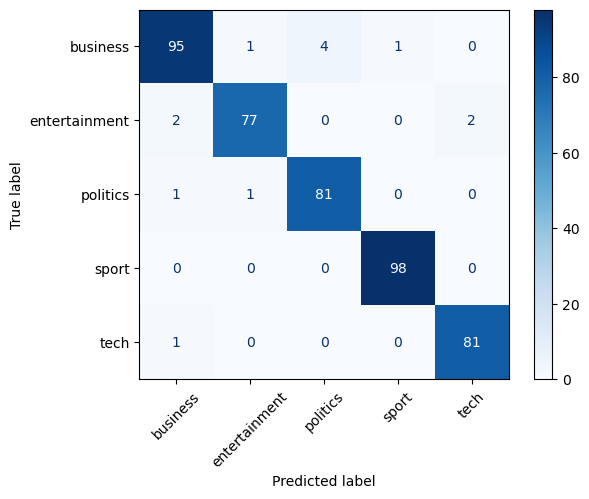

In [82]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.xticks(rotation=45)
plt.show()

# Error Analysis

In [85]:
results = pd.DataFrame({
    'text': X_test_raw,
    'actual': y_test,
    'predicted': y_pred
})

errors = results[results['actual'] != results['predicted']]

In [87]:
errors.head()

,text,actual,predicted
275,report attacks defence spending the ministry o...,politics,business
535,pc ownership to double by the number of person...,tech,business
179,arsenal may seek full share listing arsenal vi...,business,sport
554,bnp leader nick griffin arrested the leader of...,politics,entertainment
2201,ban on forced retirement under employers will ...,business,politics
